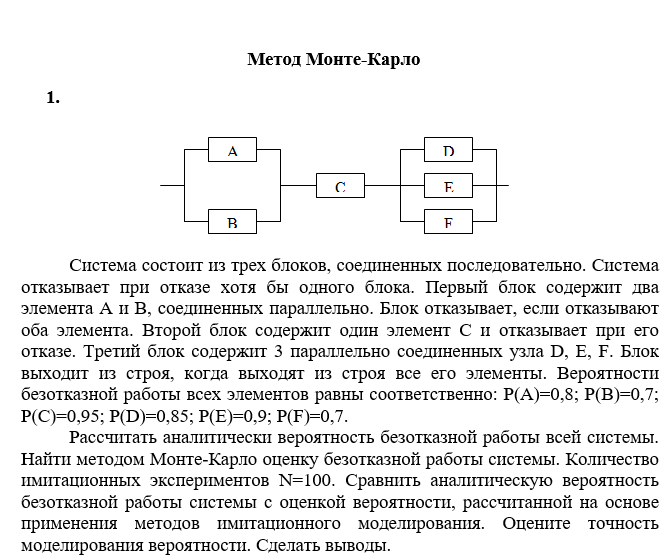

In [16]:
import random

pA, pB, pC, pD, pE, pF = 0.8, 0.7, 0.95, 0.85, 0.9, 0.7
N = 100
random.seed(37)

block1 = 1 - (1 - pA) * (1 - pB)
block2 = pC
block3 = 1 - (1 - pD) * (1 - pE) * (1 - pF)
P_analyt = block1 * block2 * block3

def system_works():
    A = random.random() < pA
    B = random.random() < pB
    C = random.random() < pC
    D = random.random() < pD
    E = random.random() < pE
    F = random.random() < pF
    return (A or B) and C and (D or E or F)

results = sum(system_works() for _ in range(N))
P_mc = results / N

print(f"аналитическая вероятность {P_analyt:.6f}")
print(f"Монте-Карло: {P_mc:.6f}")
print(f"абсолютная погрешность {abs(P_analyt - P_mc):.6f}")

аналитическая вероятность 0.888981
Монте-Карло: 0.870000
абсолютная погрешность 0.018981


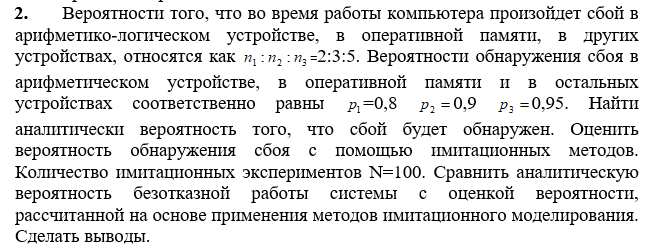

In [17]:
n1, n2, n3 = 2, 3, 5
total = n1 + n2 + n3
p1, p2, p3 = 0.8, 0.9, 0.95

P_analyt = (n1/total)*p1 + (n2/total)*p2 + (n3/total)*p3
random.seed(37)

def detect_failure():
    r = random.random()
    if r < n1/total:
        return random.random() < p1
    elif r < (n1+n2)/total:
        return random.random() < p2
    else:
        return random.random() < p3

results = sum(detect_failure() for _ in range(N))
P_mc = results / N

print(f"аналитическая вероятность: {P_analyt:.6f}")
print(f"Монте-Карло: {P_mc:.6f}")
print(f"погрешность {abs(P_analyt - P_mc):.6f}")

аналитическая вероятность: 0.905000
Монте-Карло: 0.920000
погрешность 0.015000


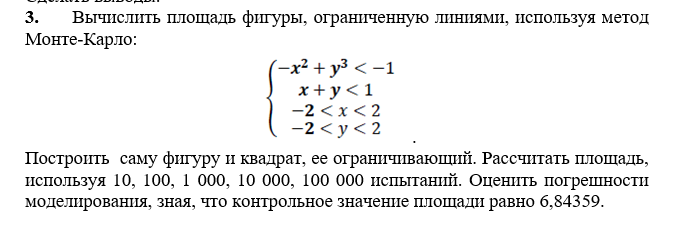

In [18]:
x_min, x_max = -2, 2
y_min, y_max = -2, 2
square_area = (x_max - x_min) * (y_max - y_min)

control_area = 6.84359
random.seed(37)

def point_in_figure(x, y):
    return (y**3 < x**2 - 1) and (x + y < 1)

def mc_area(n_trials):
    hits = 0
    points_in_x, points_in_y = [], []
    points_out_x, points_out_y = [], []
    for _ in range(n_trials):
        x = random.uniform(x_min, x_max)
        y = random.uniform(y_min, y_max)
        if point_in_figure(x, y):
            hits += 1
            points_in_x.append(x)
            points_in_y.append(y)
        else:
            points_out_x.append(x)
            points_out_y.append(y)
    area = (hits / n_trials) * square_area
    return area, hits, points_in_x, points_in_y, points_out_x, points_out_y

print(f"контрольная площадь {control_area}")
print(f"площадь квадрата {square_area}")
print("N оценка погрешность")

for n in [10, 100, 1000, 10000, 100000]:
    area, hits, px_in, py_in, px_out, py_out = mc_area(n)
    err = abs(area - control_area)
    print(f"{n} {area:.6f} {err:.6f}")
    if n == 1000:
        area_1000 = area
        hits_1000 = hits
        px_in_1000, py_in_1000 = px_in, py_in
        px_out_1000, py_out_1000 = px_out, py_out

контрольная площадь 6.84359
площадь квадрата 16
N оценка погрешность
10 4.800000 2.043590
100 8.160000 1.316410
1000 6.992000 0.148410
10000 6.796800 0.046790
100000 6.823680 0.019910


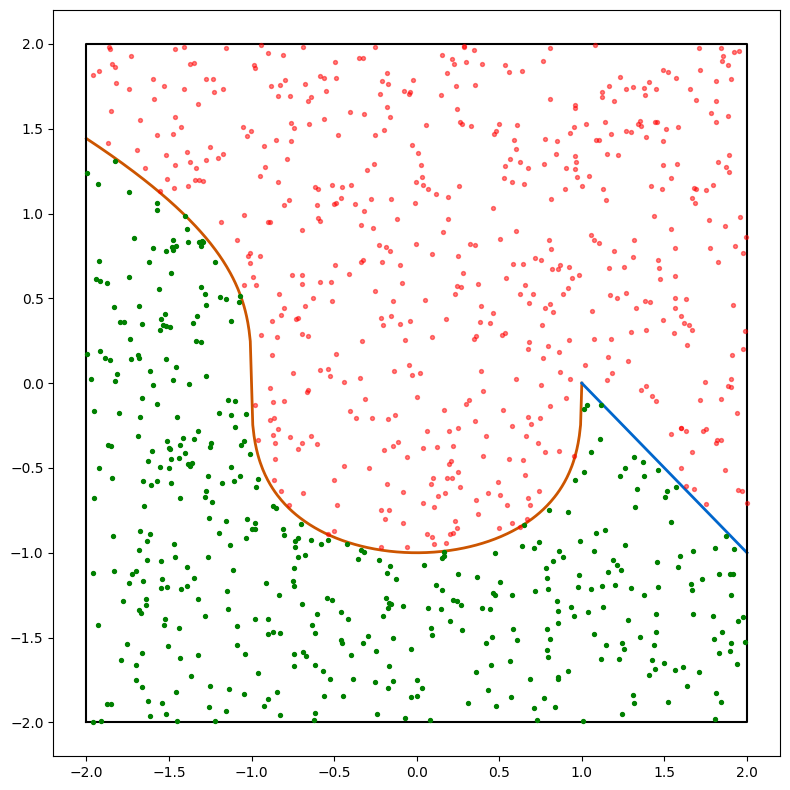

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random

x_min, x_max = -2, 2
y_min, y_max = -2, 2
control_area = 6.84359
random.seed(37)
np.random.seed(37)

N = 1000
points_in_x, points_in_y = [], []
points_out_x, points_out_y = [], []

for _ in range(N):
    x = random.uniform(x_min, x_max)
    y = random.uniform(y_min, y_max)
    if point_in_figure(x, y):
        points_in_x.append(x)
        points_in_y.append(y)
    else:
        points_out_x.append(x)
        points_out_y.append(y)

fig, ax = plt.subplots(figsize=(8, 8))

xx = np.linspace(x_min, x_max, 800)
yy = np.linspace(y_min, y_max, 800)
X, Y = np.meshgrid(xx, yy)

x_curve = np.linspace(x_min, 1, 400)
y_curve = np.cbrt(x_curve**2 - 1)
ax.plot(x_curve, y_curve, color='#cc5500', linewidth=2)

x_line = np.linspace(1, x_max, 100)
y_line = 1 - x_line
ax.plot(x_line, y_line, color='#0066cc', linewidth=2)

ax.scatter(px_in_1000, py_in_1000, s=8, color='green', label=f'Внутри ({len(px_in_1000)})', zorder=3)
ax.scatter(px_out_1000, py_out_1000, s=8, color='red', alpha=0.5, label=f'Снаружи ({len(px_out_1000)})', zorder=3)

ax.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

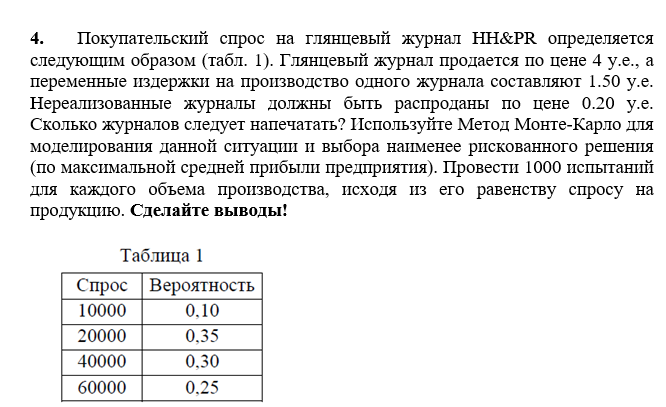

In [20]:
demands = [10000, 20000, 40000, 60000]
probs = [0.10, 0.35, 0.30, 0.25]
price = 4.0
var_cost = 1.5
salvage = 0.2
random.seed(37)

def get_demand():
    r = random.random()
    c = 0
    for d, p in zip(demands, probs):
        c += p
        if r <= c:
            return d
    return demands[-1]

def simulate_profit(print_qty):
    total_profit = 0
    for _ in range(1000):
        d = get_demand()
        sold = min(print_qty, d)
        leftover = max(0, print_qty - d)
        profit = sold * price - print_qty * var_cost + leftover * salvage
        total_profit += profit
    return total_profit / 1000

for q in [10000, 20000, 40000, 60000]:
    avg_profit = simulate_profit(q)
    print(f"тираж {q:5d}, средняя прибыль {avg_profit:.2f} у.е.")

тираж 10000, средняя прибыль 25000.00 у.е.
тираж 20000, средняя прибыль 46618.00 у.е.
тираж 40000, средняя прибыль 63140.00 у.е.
тираж 60000, средняя прибыль 56520.00 у.е.


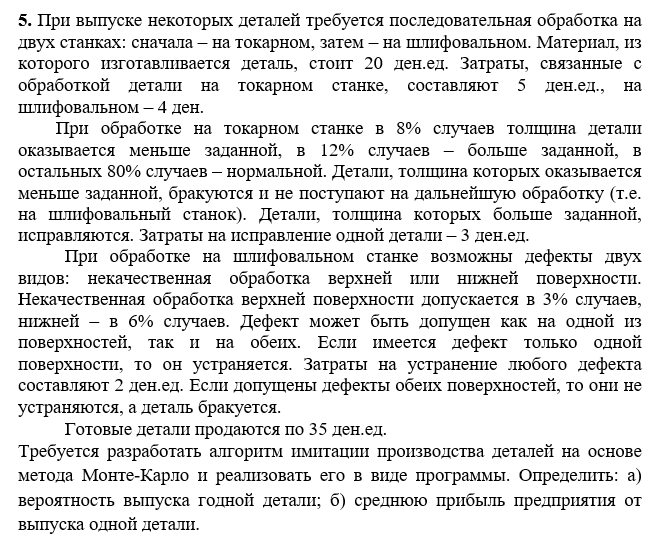

In [22]:
material_cost = 20
turning_cost = 5
grinding_cost = 4
rework_cost = 3
defect_fix_cost = 2
sale_price = 35
prob_too_small = 0.08
prob_too_large = 0.12
prob_defect_top = 0.03
prob_defect_bottom = 0.06
random.seed(37)

def simulate_one_detail():
    r = random.random()
    if r < prob_too_small:
        profit = -(material_cost + turning_cost)
        return profit, "брак на токарном"
    elif r < prob_too_small + prob_too_large:
        turning_total = turning_cost + rework_cost
    else:
        turning_total = turning_cost

    defect_top = random.random() < prob_defect_top
    defect_bottom = random.random() < prob_defect_bottom

    if defect_top and defect_bottom:
        profit = -(material_cost + turning_total+ grinding_cost)
        return profit, "брак на шлифовальном (оба дефекта)"

    grinding_total = grinding_cost
    if defect_top or defect_bottom:
        grinding_total += defect_fix_cost

    total_cost = material_cost + turning_total + grinding_total
    profit = sale_price - total_cost
    return profit, "годная"

n_trials = 10000
good_count = 0
total_profit = 0
bad_reasons = {"брак на токарном": 0, "брак на шлифовальном (оба дефекта)": 0}

for _ in range(n_trials):

    profit, status = simulate_one_detail()

    total_profit += profit

    if status == "годная":
        good_count += 1
    else:
        bad_reasons[status] += 1

prob_good = good_count / n_trials
avg_profit = total_profit / n_trials

print(f"всего деталей: {n_trials}")
print(f"годных деталей: {good_count}")
print(f"вероятность выпуска годной детали: {prob_good:.4f}")
print(f"средняя прибыль на одну деталь: {avg_profit:.2f} ден. ед.")

print("причины брака:")

for reason, count in bad_reasons.items():
    print(f"{reason}: {count}")

всего деталей: 10000
годных деталей: 9239
вероятность выпуска годной детали: 0.9239
средняя прибыль на одну деталь: 3.11 ден. ед.
причины брака:
брак на токарном: 751
брак на шлифовальном (оба дефекта): 10


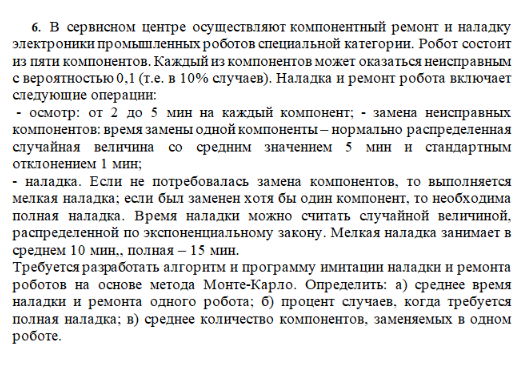

In [23]:
n_components = 5
fail_prob = 0.1
random.seed(37)
n_trials = 10000
times = []
full_count = 0
replaced_list = []

def inspect_time():
    return random.uniform(2, 5)

def replace_time():
    return max(0.1, random.gauss(5, 1))

def adjustment_time(full_setup):
    mean = 15 if full_setup else 10
    return random.expovariate(1 / mean)

def simulate_one_robot():
    total_time = 0
    replaced = 0

    for _ in range(n_components):
        total_time += inspect_time()
        if random.random() < fail_prob:
            replaced += 1
            total_time += replace_time()

    full_setup = replaced > 0
    total_time += adjustment_time(full_setup)

    return total_time, full_setup, replaced

for _ in range(n_trials):
    t, full, replaced = simulate_one_robot()
    times.append(t)
    if full:
        full_count += 1
    replaced_list.append(replaced)

mean_time = sum(times) / n_trials
percent_full = (full_count / n_trials) * 100
mean_replaced = sum(replaced_list) / n_trials

print(f"количество имитаций {n_trials}")
print(f"среднее время ремонта одного робота {mean_time:.2f} мин")
print(f"процент случаев с полной наладкой {percent_full:.2f}%")
print(f"среднее количество заменяемых компонентов {mean_replaced:.2f} шт.")

количество имитаций 10000
среднее время ремонта одного робота 32.28 мин
процент случаев с полной наладкой 41.05%
среднее количество заменяемых компонентов 0.50 шт.
